## 과제 목표
PyTorch나 TensorFlow와 같은 딥러닝 프레임워크를 전혀 사용하지 않고, 오직 Python과 `NumPy` 행렬 연산만을 이용하여 1-Hidden Layer 인공신경망의 순전파(Forward Propagation)와 역전파(Backpropagation)를 바닥부터 구현합니다. 

이를 통해 가상의 차량 동역학 센서 데이터(속도, 종/횡 가속도, 요레이트)를 3가지 주행 상태(직진, 급제동, 급선회)로 분류하는 모델을 학습시킵니다.

**[구현 지침]**
- `TODO`로 표시된 영역의 코드를 수학적 지식에 기반하여 직접 채워 넣으세요.
- 행렬 곱셈 시 `ValueError: shapes not aligned` 에러가 발생한다면 변수의 `.shape`를 출력하여 차원을 확인하세요.

In [1]:
!curl -L -o driving-behavior-dataset.zip\
  https://www.kaggle.com/api/v1/datasets/download/shashwatwork/driving-behavior-dataset

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 6790k  100 6790k    0     0  3437k      0  0:00:01  0:00:01 --:--:-- 7884k


: 

: 

In [2]:
import zipfile
# zip 파일 열기 및 압축 해제
with zipfile.ZipFile('driving-behavior-dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('driving-behavior-dataset')

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. 실제 차량 동역학 센서 데이터 (sensor_raw.csv) 로드
# ---------------------------------------------------------
def load_sensor_raw_data(csv_path='sensor_raw.csv', test_ratio=0.2):
    """
    가속도(AccX, AccY, AccZ) 및 자이로스코프(GyroX, GyroY, GyroZ) Raw 데이터를 로드합니다.
    클래스: 1(급가속), 2(우회전), 3(좌회전), 4(급제동)
    """
    try:
        df = pd.read_csv(csv_path)
    except FileNotFoundError:
        raise FileNotFoundError(f"'{csv_path}' 파일을 찾을 수 없습니다. 경로를 확인하세요.")

    # 결측치 제거
    df = df.dropna()

    # 컬럼명이 'Class', 'Label', 'Target' 등으로 다를 수 있으므로 마지막 컬럼을 라벨로 지정합니다.
    feature_cols = df.columns[1:]
    label_col = df.columns[0]

    X = df[feature_cols].values

    # 모델 학습을 위해 라벨(1, 2, 3, 4)을 (0, 1, 2, 3) 형태의 인덱스로 변환합니다.
    Y = df[label_col].values.astype(int) - 1

    # 데이터셋 셔플링 (랜덤 시드 고정)
    np.random.seed(42)
    indices = np.arange(len(X))
    np.random.shuffle(indices)
    X = X[indices]
    Y = Y[indices]

    # Train / Test 분할
    split_idx = int(len(X) * (1 - test_ratio))
    X_train, X_test = X[:split_idx], X[split_idx:]
    Y_train, Y_test = Y[:split_idx], Y[split_idx:]

    # 데이터 정규화 (Standardization)
    # 훈련 데이터의 평균과 표준편차를 구한 뒤, 테스트 데이터에도 동일하게 적용합니다.
    mean_X = X_train.mean(axis=0)
    std_X = X_train.std(axis=0)
    std_X[std_X == 0] = 1e-8 # 0으로 나누어지는 오류 방지

    X_train = (X_train - mean_X) / std_X
    X_test = (X_test - mean_X) / std_X

    return X_train, Y_train, X_test, Y_test

# 데이터 로드 실행 (CSV 파일이 같은 폴더에 있다고 가정)
X_train, Y_train, X_test, Y_test = load_sensor_raw_data('driving-behavior-dataset/sensor_raw.csv')

# --- [중요] 클래스 개수가 4개로 변경되었으므로 파라미터 업데이트 ---
output_size = 4
Y_train_one_hot = np.eye(output_size)[Y_train]

print(f"Train Features Shape: {X_train.shape}")
print(f"Train Labels Shape (One-hot): {Y_train_one_hot.shape}")
print(f"Test Features Shape: {X_test.shape}")

# 실제 데이터의 클래스 분포 확인
unique, counts = np.unique(Y_train, return_counts=True)
class_names = ['Accel (0)', 'Right (1)', 'Left (2)', 'Brake (3)']
distribution = {class_names[k]: v for k, v in zip(unique, counts)}
print(f"\nClass Distribution (Train): {distribution}")

Train Features Shape: (891, 6)
Train Labels Shape (One-hot): (891, 4)
Test Features Shape: (223, 6)

Class Distribution (Train): {'Accel (0)': np.int64(209), 'Right (1)': np.int64(237), 'Left (2)': np.int64(269), 'Brake (3)': np.int64(176)}


### 1. 파라미터 초기화
네트워크의 가중치($W$)와 편향($b$)을 초기화합니다. 각 행렬의 차원(Shape)이 어떻게 구성되어야 하는지 명확히 이해하고 코드를 작성하세요.

In [9]:
input_size = X_train.shape[1]
hidden_size = 16
learning_rate = 0.1

# np.random.randn 등을 사용하여 가중치는 작게, 편향은 0으로 초기화합니다.
W1 = np.random.randn(input_size, hidden_size) * 0.01
b1 = np.zeros((1, hidden_size))
W2 = np.random.randn(hidden_size, output_size) * 0.01
b2 = np.zeros((1, output_size))

### 2. 모델 학습 루프 (Training Loop)
아래의 빈칸(`TODO`)에 순전파, 손실 함수 계산, 역전파, 가중치 업데이트 코드를 직접 구현하세요.

Epoch [50/5000], Loss: 1.3743
Epoch [100/5000], Loss: 1.3640
Epoch [150/5000], Loss: 1.3102
Epoch [200/5000], Loss: 1.2457
Epoch [250/5000], Loss: 1.2088
Epoch [300/5000], Loss: 1.1850
Epoch [350/5000], Loss: 1.1630
Epoch [400/5000], Loss: 1.1401
Epoch [450/5000], Loss: 1.1149
Epoch [500/5000], Loss: 1.0848
Epoch [550/5000], Loss: 1.0482
Epoch [600/5000], Loss: 1.0092
Epoch [650/5000], Loss: 0.9750
Epoch [700/5000], Loss: 0.9477
Epoch [750/5000], Loss: 0.9265
Epoch [800/5000], Loss: 0.9101
Epoch [850/5000], Loss: 0.8973
Epoch [900/5000], Loss: 0.8870
Epoch [950/5000], Loss: 0.8784
Epoch [1000/5000], Loss: 0.8710
Epoch [1050/5000], Loss: 0.8644
Epoch [1100/5000], Loss: 0.8586
Epoch [1150/5000], Loss: 0.8533
Epoch [1200/5000], Loss: 0.8484
Epoch [1250/5000], Loss: 0.8438
Epoch [1300/5000], Loss: 0.8395
Epoch [1350/5000], Loss: 0.8353
Epoch [1400/5000], Loss: 0.8314
Epoch [1450/5000], Loss: 0.8277
Epoch [1500/5000], Loss: 0.8242
Epoch [1550/5000], Loss: 0.8210
Epoch [1600/5000], Loss: 0.8

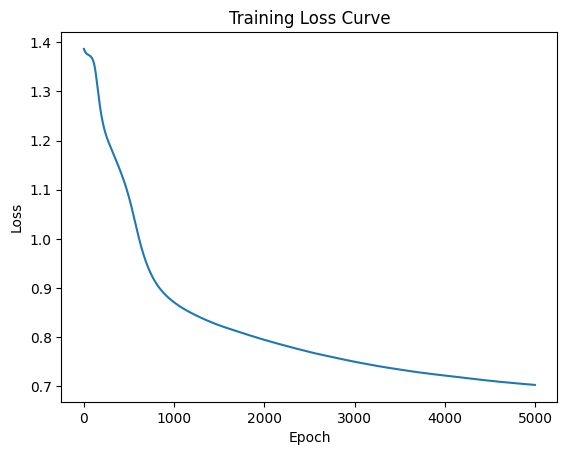

In [10]:
epochs = 5000
losses = []
m = X_train.shape[0] # 배치 사이즈

for epoch in range(epochs):
    # ================================================================
    # [TODO 1] 순전파 (Forward Propagation)
    # ================================================================
    Z1 = X_train @ W1 + b1
    A1 = np.maximum(0,Z1)
    Z2 = A1 @ W2 + b2
    exp_Z2 = np.exp(Z2 - np.max(Z2, axis=1, keepdims=True))
    probs = exp_Z2 / np.sum(exp_Z2, axis=1, keepdims=True)
    
    # ================================================================
    # [TODO 2] 손실 함수 (Cross Entropy Loss)
    # 수식 참고: https://docs.pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html#torch.nn.CrossEntropyLoss
    # 구현 참고: https://github.com/pytorch/pytorch/blob/874a17dc2ad591c8f23d61e13b3ef2f8e995afa8/aten/src/ATen/native/LossNLL.cpp#L498
    # ================================================================
    # log(0)으로 인한 NaN 발생을 막기 위해 아주 작은 값(1e-8)을 더해줍니다.
    loss = - np.sum(Y_train_one_hot * np.log(probs + 1e-8)) / m
    losses.append(loss)

    # ================================================================)
    # [TODO 3] 역전파 (Backward Propagation)
    # ================================================================
    dZ2 = (probs - Y_train_one_hot) / m
    dW2 = A1.T @ dZ2
    db2 = np.sum(dZ2, axis=0, keepdims=True)
    dA1 = dZ2 @ W2.T
    dZ1 = dA1 * (Z1 > 0)
    dW1 = X_train.T @ dZ1
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    # ================================================================
    # [TODO 4] 가중치 업데이트 (Gradient Descent)
    # ================================================================
    W1 = W1 - learning_rate*dW1
    b1 = b1 - learning_rate*db1
    W2 = W2 - learning_rate*dW2
    b2 = b2 - learning_rate*db2

    if (epoch+1) % 50 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss:.4f}') # loss 변수가 정상적으로 계산되어야 출력됨

# 학습 곡선 시각화
plt.plot(losses)
plt.title('Training Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

### 3. 평가 및 시각화 (Evaluation & Visualization)
학습이 끝난 모델을 바탕으로 전체 데이터(Train+Test)에 대한 추론을 진행하고, 모델이 데이터를 올바르게 군집화했는지 시각적으로 확인합니다. 데이터가 4차원이므로, 가장 특징적인 두 축(종방향 가속도, 요레이트)을 기준으로 2D 산점도(Scatter plot)를 그립니다.

Overall Accuracy: 68.61%

PCA Explained Variance Ratio: PC1(0.44), PC2(0.18)


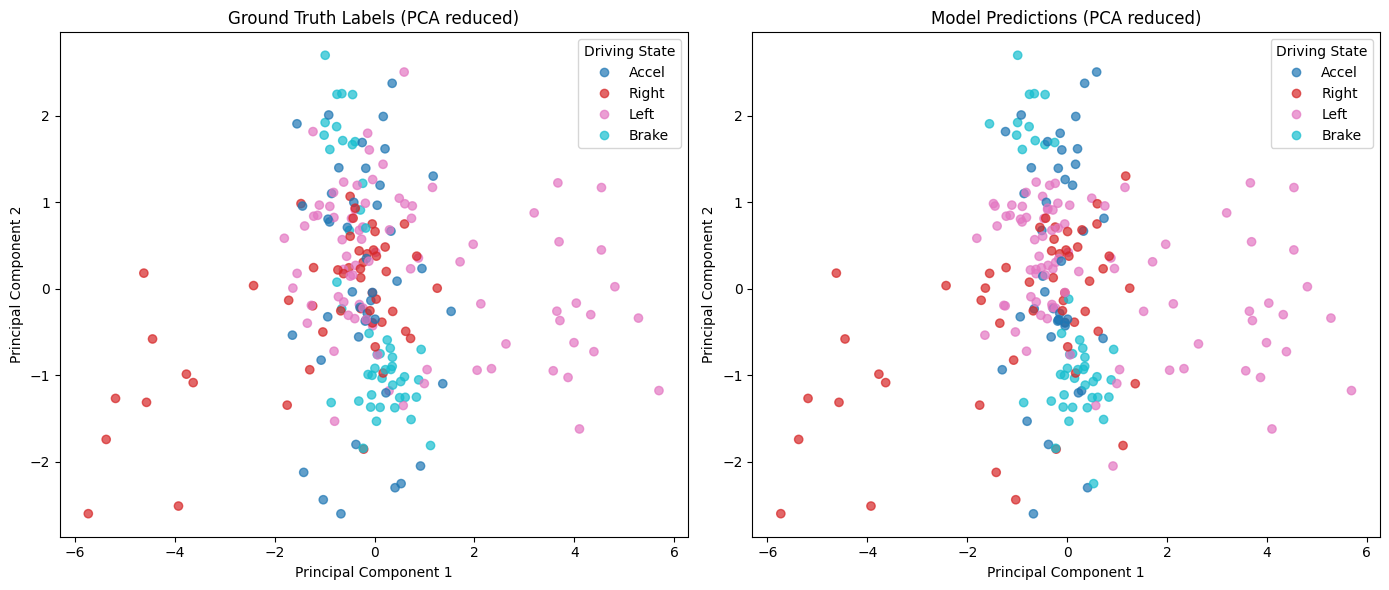

: 

: 

: 

In [11]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. 모델 추론 (Test 데이터 대상)
# ---------------------------------------------------------
# 학습된 W, b를 사용하여 전체 데이터셋 Forward Pass
Z1_all = X_test @ W1 + b1
A1_all = np.maximum(0, Z1_all)
Z2_all = A1_all @ W2 + b2
predictions_all = np.argmax(Z2_all, axis=1)

# 정확도 계산
accuracy = np.mean(predictions_all == Y_test)
print(f'Overall Accuracy: {accuracy * 100:.2f}%\n')

# ---------------------------------------------------------
# 2. 결과 시각화 (PCA를 활용한 2차원 축소)
# ---------------------------------------------------------
# 6차원의 특징(Feature) 공간을 2차원으로 축소하여 데이터의 분포를 시각화합니다.
pca = PCA(n_components=2)
X_all_2d = pca.fit_transform(X_test)

# PCA의 설명 분산 비율 출력
explained_variance = pca.explained_variance_ratio_
print(f"PCA Explained Variance Ratio: PC1({explained_variance[0]:.2f}), PC2({explained_variance[1]:.2f})")

# t-SNE 적용 시 아래 주석 해제
# tsne = TSNE(n_components=2, random_state=42)
# X_all_2d = tsne.fit_transform(X_all)

plt.figure(figsize=(14, 6))
class_labels = ['Accel', 'Right', 'Left', 'Brake']

# 왼쪽: Ground Truth Labels
plt.subplot(1, 2, 1)
# 이산형 데이터에 적합한 tab10 컬러맵 사용
scatter1 = plt.scatter(X_all_2d[:, 0], X_all_2d[:, 1],
                       c=Y_test, cmap='tab10', alpha=0.7, edgecolors=None)
plt.title('Ground Truth Labels (PCA reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
# Colorbar 대신 Legend 적용
plt.legend(handles=scatter1.legend_elements()[0], labels=class_labels, title="Driving State")

# 오른쪽: Model Predictions
plt.subplot(1, 2, 2)
scatter2 = plt.scatter(X_all_2d[:, 0], X_all_2d[:, 1],
                       c=predictions_all, cmap='tab10', alpha=0.7, edgecolors=None)
plt.title('Model Predictions (PCA reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
# Colorbar 대신 Legend 적용
plt.legend(handles=scatter2.legend_elements()[0], labels=class_labels, title="Driving State")

plt.tight_layout()
plt.show()